In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf
from IPython.display import display

In [2]:
# 1. Tải và xem trước dữ liệu
df = pd.read_csv('../data/raw/daily-min-temperatures.csv', parse_dates=['Date'], index_col='Date')
display(df.head())
display(df.info())

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


<class 'pandas.DataFrame'>
DatetimeIndex: 3650 entries, 1981-01-01 to 1990-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Temp    3650 non-null   float64
dtypes: float64(1)
memory usage: 57.0 KB


None

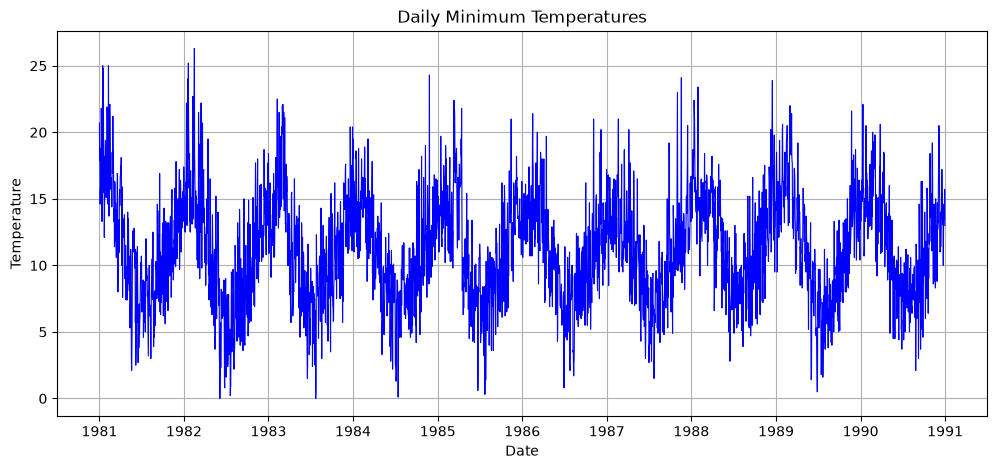

In [3]:
# Vẽ plot tổng quan
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Temp'], color='blue', linewidth=0.8)
plt.title('Daily Minimum Temperatures')
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.grid(True)
plt.show()

In [10]:
# 2. Tính ACF, PACF đến 40 lags.
# Tính các giá trị ACF & PACF (40 lags)
acf_values = acf(df['Temp'], nlags=40)
pacf_values = pacf(df['Temp'], nlags=40, method='ywm')
print(" Giá trị ACF (40 lags) ")
print(acf_values)
print("\n Giá trị PACF (40 lags) ")
print(pacf_values)


 Giá trị ACF (40 lags) 
[1.         0.774268   0.6302866  0.58529312 0.57774567 0.57728013
 0.57510412 0.57437039 0.56782622 0.56120131 0.54668689 0.53793111
 0.54012564 0.54247126 0.53688723 0.53429917 0.53043593 0.52911166
 0.53037444 0.52280732 0.52303677 0.52224579 0.51426684 0.49837745
 0.49302665 0.49946731 0.50428521 0.50068173 0.49157081 0.48146406
 0.47421245 0.47568054 0.46311862 0.46215585 0.46630567 0.45459092
 0.43378232 0.4203594  0.42707505 0.42196486 0.4079607 ]

 Giá trị PACF (40 lags) 
[ 1.00000000e+00  7.74268002e-01  7.68912907e-02  1.89057786e-01
  1.51724252e-01  1.29451487e-01  1.09110563e-01  1.02801877e-01
  7.39925795e-02  6.97976999e-02  3.50866667e-02  4.76674634e-02
  6.01486719e-02  5.05787779e-02  3.22628905e-02  4.50175277e-02
  3.13790412e-02  3.90424525e-02  4.07371723e-02  1.38081870e-02
  4.10276037e-02  2.47804204e-02  8.56378650e-03 -1.08501868e-02
  1.47453908e-02  3.06974043e-02  2.43686611e-02  1.04223193e-02
  2.90022333e-03 -3.10081195e-03 -9.

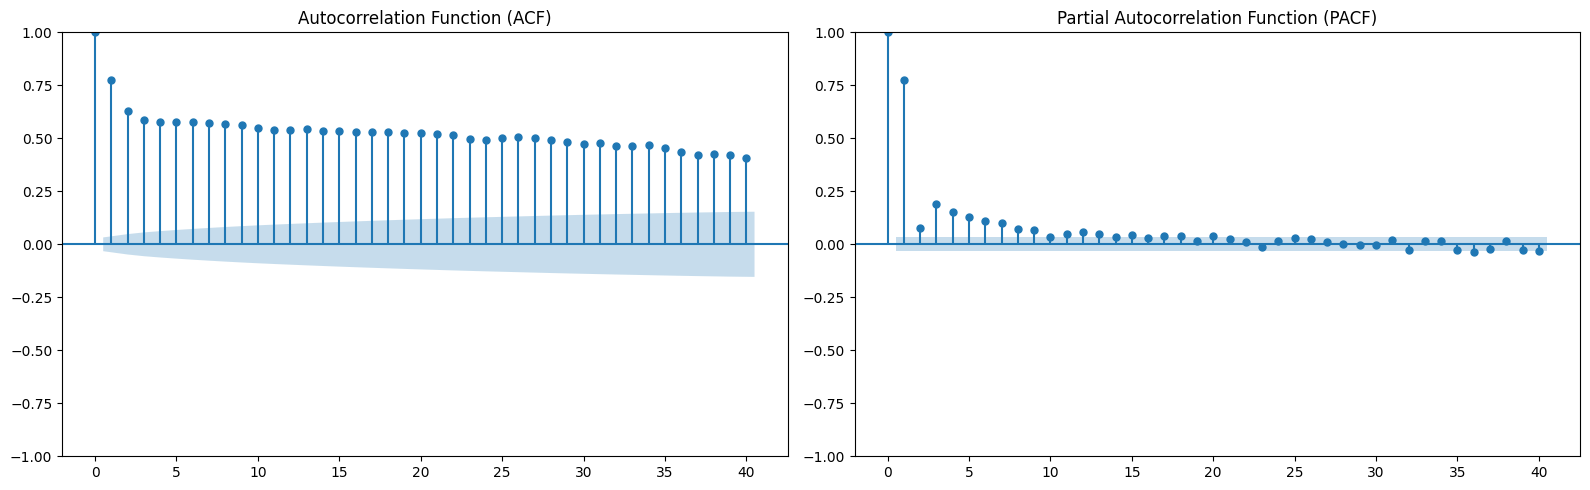

In [11]:
# Biểu đồ tổng quan ACF & PACF
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
# ACF
plot_acf(df['Temp'], lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')
# PACF
plot_pacf(df['Temp'], lags=40, ax=axes[1], method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF)')
plt.tight_layout()
plt.show()


### 3.Kết Luận


### Bài tập 2

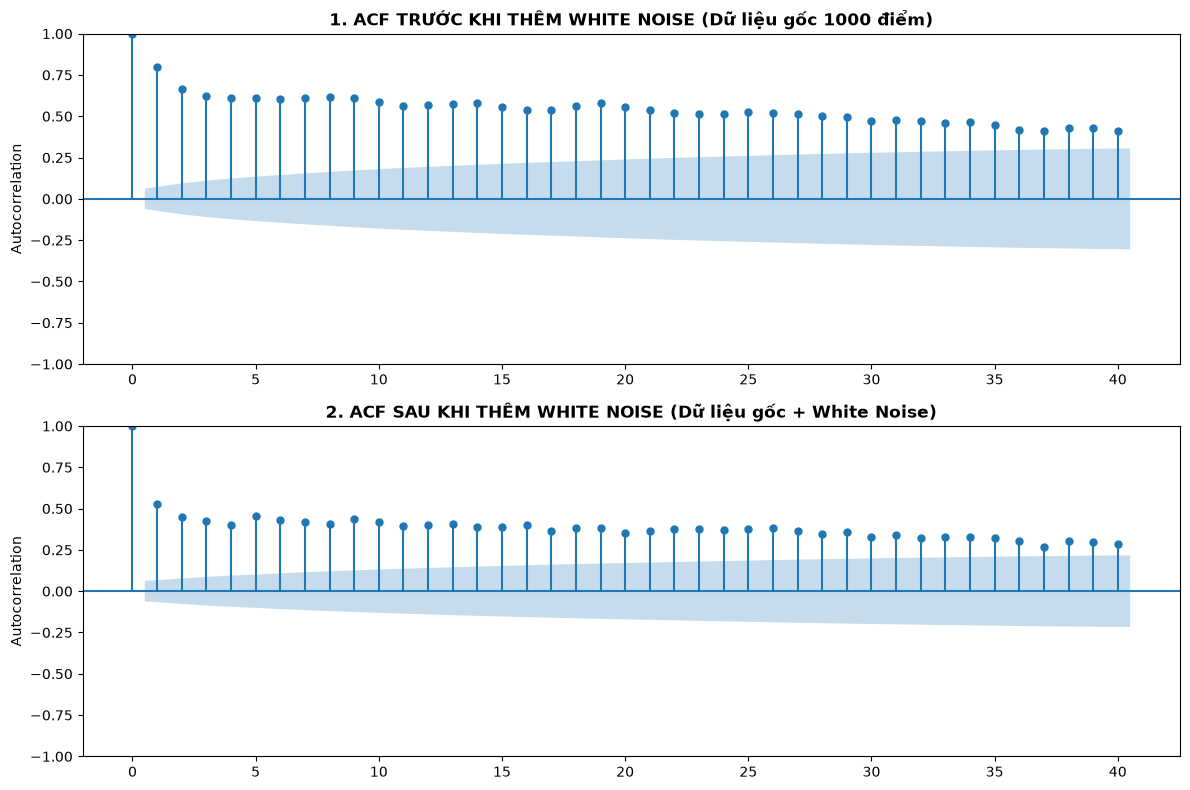

In [5]:
# ==============================================================
# BÀI TẬP 2: LỒNG WHITE NOISE VÀO DỮ LIỆU BAN ĐẦU & SO SÁNH ACF
# ==============================================================

# 1. Lấy 1000 điểm từ dữ liệu nhiệt độ ban đầu
N = 1000
original_data = df['Temp'].iloc[:N].copy()

# 2. Sinh 1000 điểm White Noise
np.random.seed(42)
# scale: độ lớn của nhiễu (bạn có thể chỉnh 2.0 hoặc 3.0 để thấy rõ sự khác biệt)
white_noise = np.random.normal(loc=0.0, scale=3.0, size=N)

# 3. Lồng White Noise vào dữ liệu ban đầu
noisy_data = original_data + white_noise

# 4. Vẽ 2 biểu đồ ACF để so sánh TRƯỚC và SAU khi thêm White Noise
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Biểu đồ 1: TRƯỚC khi thêm nhiễu (Dữ liệu gốc)
plot_acf(original_data, lags=40, ax=axes[0])
axes[0].set_title(
    '1. ACF TRƯỚC KHI THÊM WHITE NOISE (Dữ liệu gốc 1000 điểm)',
    fontsize=12,
    fontweight='bold',
)
axes[0].set_ylabel('Autocorrelation')

# Biểu đồ 2: SAU khi thêm nhiễu (Đã lồng White Noise)
plot_acf(noisy_data, lags=40, ax=axes[1])
axes[1].set_title(
    '2. ACF SAU KHI THÊM WHITE NOISE (Dữ liệu gốc + White Noise)',
    fontsize=12,
    fontweight='bold',
)
axes[1].set_ylabel('Autocorrelation')

plt.tight_layout()
plt.show()


Kiểm tra độ tin cậy:

In [11]:
from statsmodels.tsa.stattools import acf

# 1. Tận dụng trực tiếp biến white_noise đã sinh ở trên
ci_bound = 1.96 / np.sqrt(len(white_noise))
nlags = 40

# 2. Tính số lag nằm trong dải tin cậy 95%
acf_values = acf(white_noise, nlags=nlags)
lags_outside = np.sum(np.abs(acf_values[1:]) > ci_bound)  # Bỏ qua lag 0
lags_inside = nlags - lags_outside
pct_inside = (lags_inside / nlags) * 100

# 3. In kết quả
print(f'- Ngưỡng tin cậy 95%: [ -{ci_bound:.4f} , +{ci_bound:.4f} ]')
print(f'- Số lag vượt ngưỡng: {lags_outside}/{nlags} lag')
print(f'- Tỷ lệ lag nằm trong dải tin cậy: {pct_inside:.2f}%')

if pct_inside >= 95.0:
    print(
        f'=> KẾT LUẬN: ĐẠT trên 95% ({pct_inside:.2f}% >= 95%).'
    )
else:
    print(f'=> KẾT LUẬN: KHÔNG ĐẠT 95%.')


- Ngưỡng tin cậy 95%: [ -0.0620 , +0.0620 ]
- Số lag vượt ngưỡng: 1/40 lag
- Tỷ lệ lag nằm trong dải tin cậy: 97.50%
=> KẾT LUẬN: ĐẠT trên 95% (97.50% >= 95%).


### Đánh giá :

1. **Về độ suy giảm tự tương quan:** Sau khi thêm White Noise, hệ số ACF ở toàn bộ 40 lag giảm rõ rệt (lag 1 giảm mạnh từ ~0.80 xuống ~0.53) do nhiễu trắng làm tăng phương sai mẫu và giảm độ tương quan nội tại của chuỗi gốc.
2. **Về hình thái quy luật:** Mặc dù biên độ các cột lag bị suy giảm đáng kể, chuỗi sau khi thêm nhiễu vẫn giữ được hình thái giảm dần đều và cấu trúc chu kỳ đặc trưng của dữ liệu nhiệt độ ban đầu chứ chưa bị triệt tiêu hoàn toàn.
3. **Về vị trí so với dải tin cậy 95%:** Sau khi thêm nhiễu, toàn bộ 40 lag (100%) đều nằm vượt ra ngoài dải tin cậy 95%, vẫn có ý nghĩa thống kê.
4. **Về kiểm định tính chất White Noise:** Với độ tin cậy trên 95%, ta khẳng định chuỗi sau khi thêm nhiễu **vẫn KHÔNG PHẢI là White Noise**, vì cường độ nhiễu chưa đủ lớn để xóa bỏ hoàn toàn "bộ nhớ" quá khứ của chuỗi thời gian gốc.
5. **Về ý nghĩa mô hình hóa & dự báo:** Tỷ lệ tín hiệu trên nhiễu (SNR) bị suy giảm sẽ làm giảm độ chính xác khi dự báo, nhưng với việc các lag vẫn vượt ngưỡng tin cậy 95%, chuỗi vẫn chứa đựng lượng thông tin có giá trị để xây dựng các mô hình chuỗi thời gian (như AR/ARIMA).


### Bài tập 4

In [14]:
df_missing = pd.read_csv('../data/processed/daily-min-temperatures-missing.csv', parse_dates=['Date'], index_col='Date')
missing_count = df_missing.isna().sum()
missing_percentage = (df_missing.isna().sum() / len(df_missing)) * 100
missing_report = pd.DataFrame(
    {"Missing count": missing_count, "Percentage:": missing_percentage}
)
print(missing_report)

      Missing count  Percentage:
Temp             33      0.90411


Số lượng NaN sau khi Forward-fill: 0
Số lượng NaN sau khi Interpolation: 0


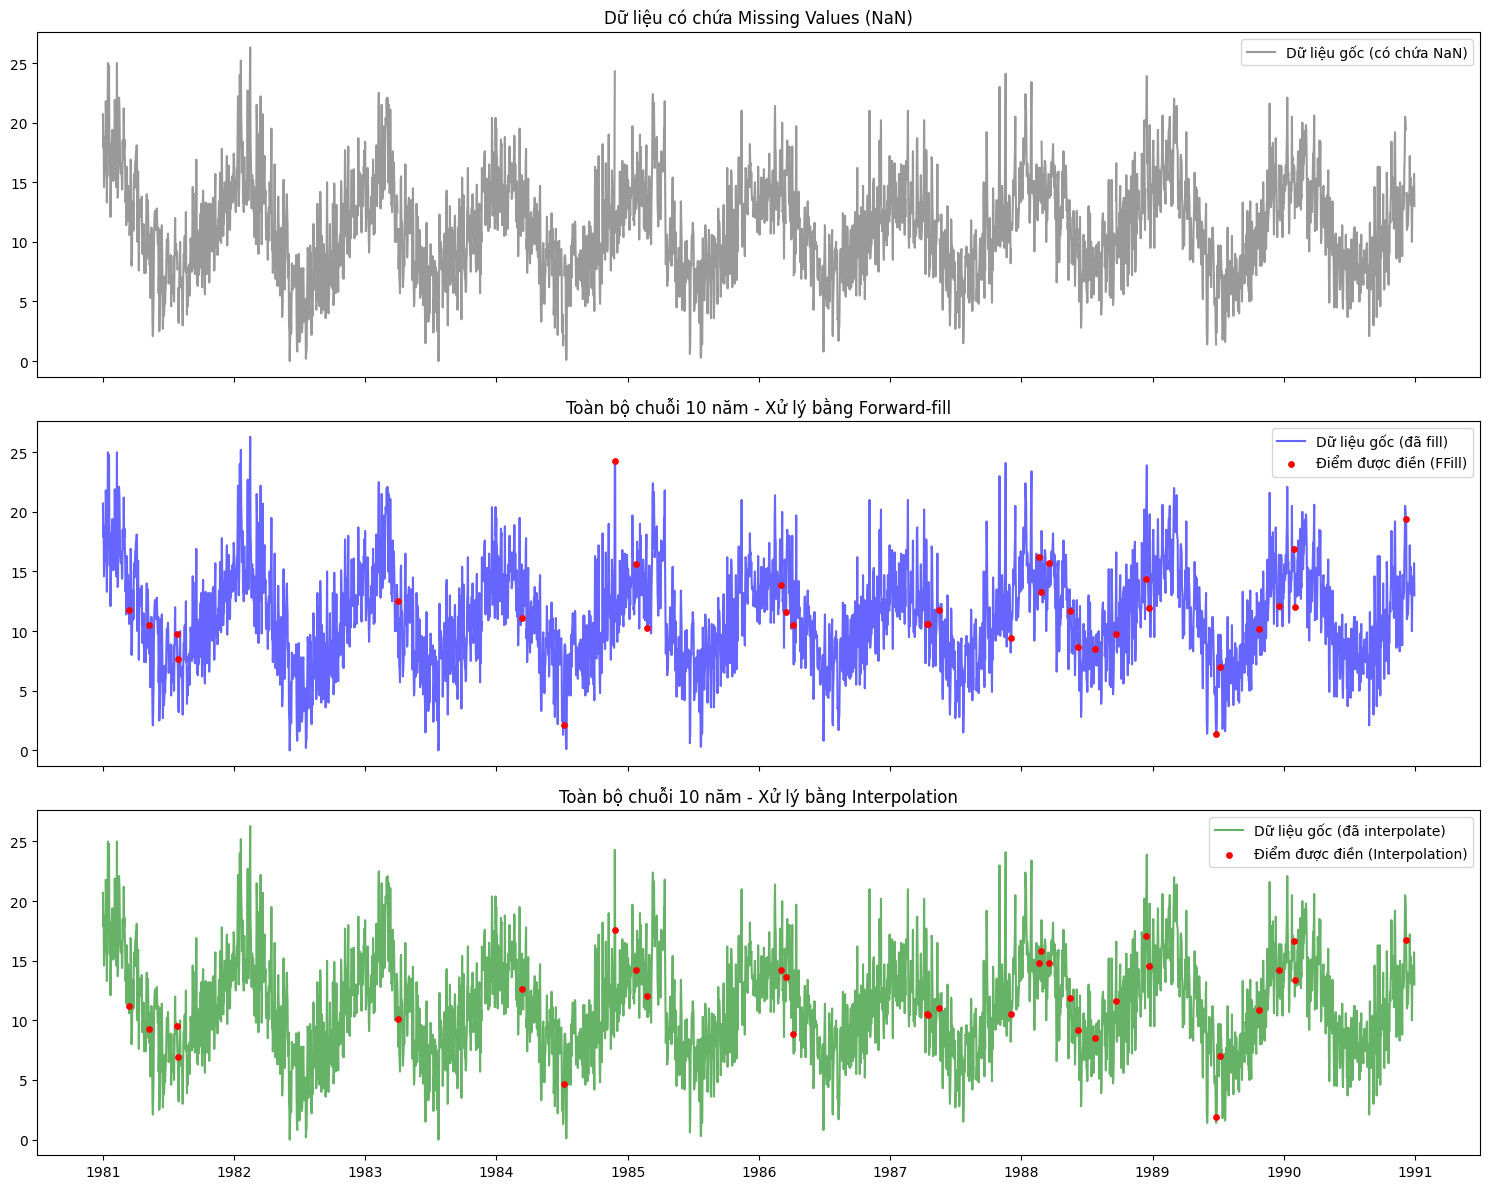

In [18]:
# Cách 1: Forward-fill
df_ffill = df_missing.copy()
df_ffill['Temp'] = df_ffill['Temp'].ffill()
print("Số lượng NaN sau khi Forward-fill:", df_ffill['Temp'].isna().sum())

# Cách 2: Interpolation
df_interp = df_missing.copy()
df_interp['Temp'] = df_interp['Temp'].interpolate(method='linear')
print("Số lượng NaN sau khi Interpolation:", df_interp['Temp'].isna().sum())

# ---------------------------------------------------------
# Vẽ biểu đồ so sánh
# ---------------------------------------------------------
missing_mask = df_missing['Temp'].isna()

# Khởi tạo 3 khung đồ thị (3 dòng)
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# 1. Vẽ toàn bộ dữ liệu bị missing lên axes[0]
axes[0].plot(df_missing.index, df_missing['Temp'], color='gray', alpha=0.8, label='Dữ liệu gốc (có chứa NaN)')
axes[0].set_title('Dữ liệu có chứa Missing Values (NaN)')
axes[0].legend()

# 2. Vẽ toàn bộ dữ liệu sau khi Forward-fill lên axes[1]
axes[1].plot(df_ffill.index, df_ffill['Temp'], color='blue', alpha=0.6, label='Dữ liệu gốc (đã fill)')
axes[1].scatter(df_ffill[missing_mask].index, df_ffill.loc[missing_mask, 'Temp'], color='red', s=15, label='Điểm được điền (FFill)', zorder=5)
axes[1].set_title('Toàn bộ chuỗi 10 năm - Xử lý bằng Forward-fill')
axes[1].legend()

# 3. Vẽ toàn bộ dữ liệu sau khi Interpolation lên axes[2]
axes[2].plot(df_interp.index, df_interp['Temp'], color='green', alpha=0.6, label='Dữ liệu gốc (đã interpolate)')
axes[2].scatter(df_interp[missing_mask].index, df_interp.loc[missing_mask, 'Temp'], color='red', s=15, label='Điểm được điền (Interpolation)', zorder=5)
axes[2].set_title('Toàn bộ chuỗi 10 năm - Xử lý bằng Interpolation')
axes[2].legend()

plt.tight_layout()
plt.show()


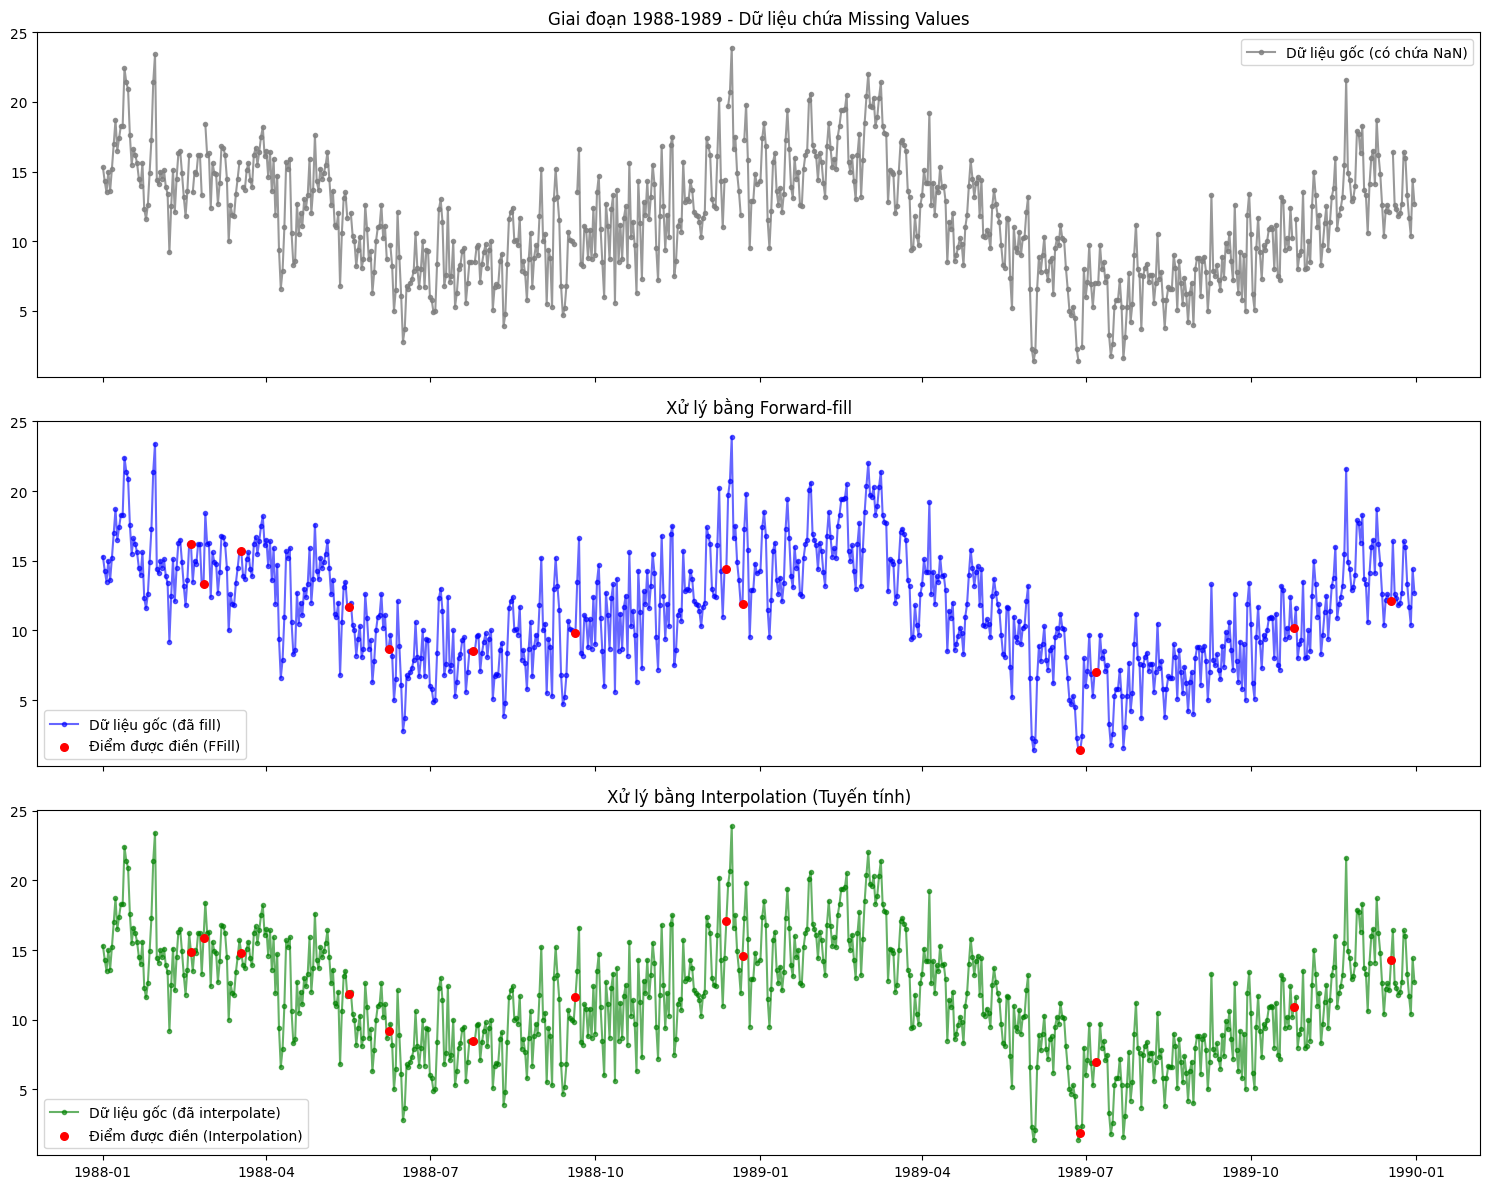

In [19]:
# Chọn khoảng thời gian cắt nhỏ
start_date = '1988-01-01'
end_date = '1989-12-31'
# Cắt dữ liệu trong khoảng thời gian đã chọn
df_missing_zoom = df_missing[start_date:end_date]
df_ffill_zoom = df_ffill[start_date:end_date]
df_interp_zoom = df_interp[start_date:end_date]
# Tìm các vị trí bị NaN trong đoạn cắt
missing_mask_zoom = df_missing_zoom['Temp'].isna()
# Tạo 3 khung đồ thị
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
# 1. Vẽ dữ liệu bị MISSING
axes[0].plot(df_missing_zoom.index, df_missing_zoom['Temp'], marker='o', markersize=3, color='gray', alpha=0.8, label='Dữ liệu gốc (có chứa NaN)')
axes[0].set_title(f'Giai đoạn {start_date[:4]}-{end_date[:4]} - Dữ liệu chứa Missing Values')
axes[0].legend()
# 2. Vẽ dữ liệu FORWARD-FILL
axes[1].plot(df_ffill_zoom.index, df_ffill_zoom['Temp'], marker='o', markersize=3, color='blue', alpha=0.6, label='Dữ liệu gốc (đã fill)')
axes[1].scatter(df_ffill_zoom[missing_mask_zoom].index, df_ffill_zoom.loc[missing_mask_zoom, 'Temp'], color='red', s=30, label='Điểm được điền (FFill)', zorder=5)
axes[1].set_title('Xử lý bằng Forward-fill')
axes[1].legend()
# 3. Vẽ dữ liệu INTERPOLATION
axes[2].plot(df_interp_zoom.index, df_interp_zoom['Temp'], marker='o', markersize=3, color='green', alpha=0.6, label='Dữ liệu gốc (đã interpolate)')
axes[2].scatter(df_interp_zoom[missing_mask_zoom].index, df_interp_zoom.loc[missing_mask_zoom, 'Temp'], color='red', s=30, label='Điểm được điền (Interpolation)', zorder=5)
axes[2].set_title('Xử lý bằng Interpolation (Tuyến tính)')
axes[2].legend()
plt.tight_layout()
plt.show()

Số lượng Outliers tìm được bằng Z-score: 10


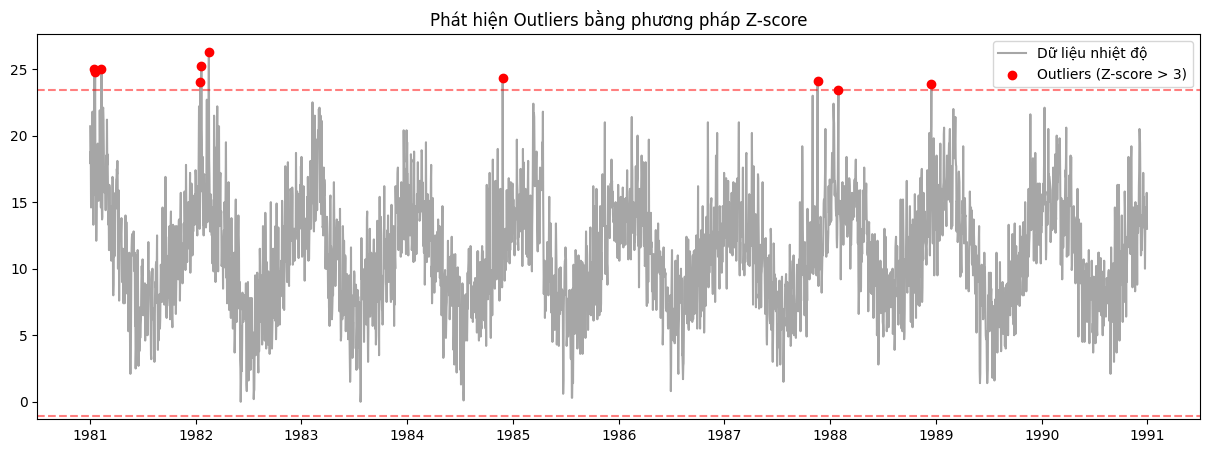

In [ ]:
# Cách 1: Dùng Z-score
df_outliers = df_interp.copy()

# Tính mean và std
mean_temp = df_outliers['Temp'].mean()
std_temp = df_outliers['Temp'].std()

# Tính Z-score cho từng dòng
df_outliers['Z_score'] = (df_outliers['Temp'] - mean_temp) / std_temp

# Xác định ngưỡng Outlier
threshold = 3
z_outliers = df_outliers[np.abs(df_outliers['Z_score']) > threshold]

print(f"Số lượng Outliers tìm được bằng Z-score: {len(z_outliers)}")

# Vẽ đồ thị
plt.figure(figsize=(15, 5))
plt.plot(df_outliers.index, df_outliers['Temp'], color='gray', alpha=0.7, label='Dữ liệu nhiệt độ')
plt.scatter(z_outliers.index, z_outliers['Temp'], color='red', label='Outliers (Z-score > 3)', zorder=5)
plt.axhline(mean_temp + threshold * std_temp, color='red', linestyle='--', alpha=0.5)
plt.axhline(mean_temp - threshold * std_temp, color='red', linestyle='--', alpha=0.5)
plt.title('Phát hiện Outliers bằng phương pháp Z-score')
plt.legend()
plt.show()


Số lượng Outliers tìm được bằng IQR: 13


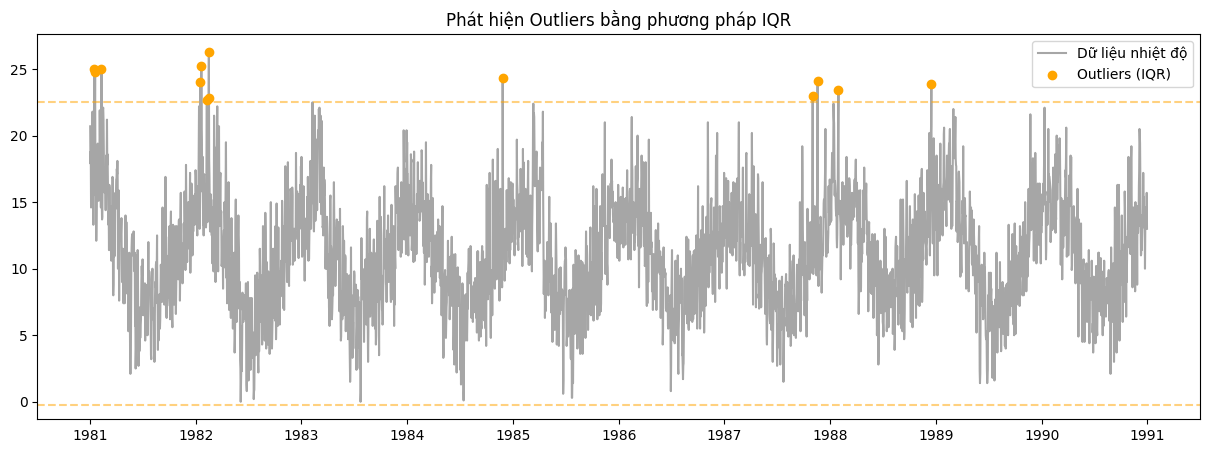

In [21]:
# Cách 2: Sử dụng IQR
# Tính Q1, Q3 và IQR
Q1 = df_outliers['Temp'].quantile(0.25)
Q3 = df_outliers['Temp'].quantile(0.75)
IQR = Q3 - Q1

# Xác định ranh giới dưới (Lower bound) và ranh giới trên (Upper bound)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Lọc ra các điểm outliers
iqr_outliers = df_outliers[(df_outliers['Temp'] < lower_bound) | (df_outliers['Temp'] > upper_bound)]

print(f"Số lượng Outliers tìm được bằng IQR: {len(iqr_outliers)}")

# Vẽ đồ thị
plt.figure(figsize=(15, 5))
plt.plot(df_outliers.index, df_outliers['Temp'], color='gray', alpha=0.7, label='Dữ liệu nhiệt độ')
plt.scatter(iqr_outliers.index, iqr_outliers['Temp'], color='orange', label='Outliers (IQR)', zorder=5)
plt.axhline(upper_bound, color='orange', linestyle='--', alpha=0.5)
plt.axhline(lower_bound, color='orange', linestyle='--', alpha=0.5)
plt.title('Phát hiện Outliers bằng phương pháp IQR')
plt.legend()
plt.show()


### Kết luận Outlier

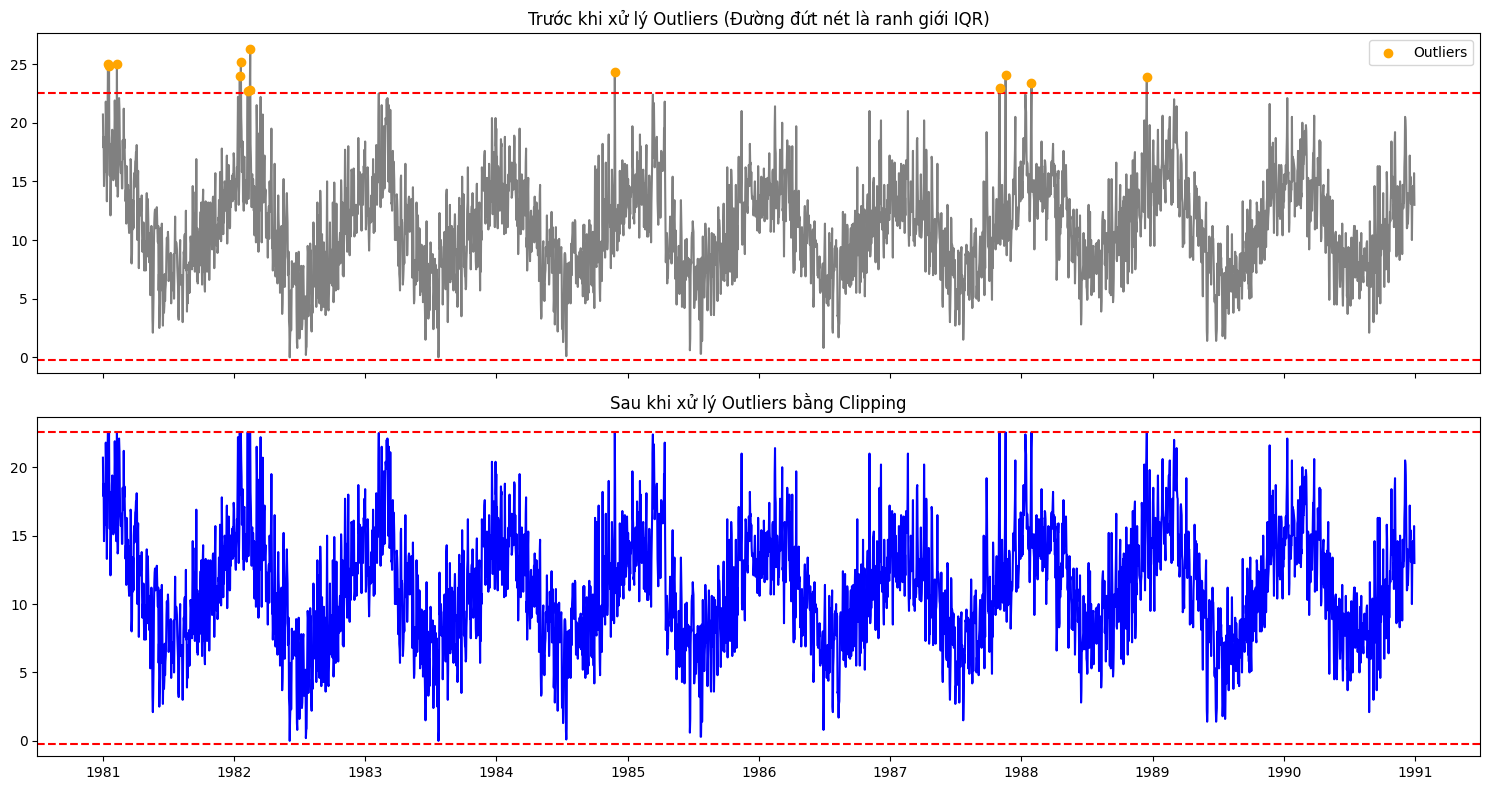

In [ ]:
# Cách 1: Xử lý bằng Clipping/ Winsorizing
df_handled = df_outliers.copy()

# Xử lý bằng cách ép các giá trị vượt ngưỡng về bằng Lower/Upper bound của IQR
df_handled['Temp'] = df_handled['Temp'].clip(lower=lower_bound, upper=upper_bound)

# Vẽ biểu đồ so sánh Trước và Sau
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# 1. Trước khi xử lý (có các gai nhọn nhô ra)
axes[0].plot(df_outliers.index, df_outliers['Temp'], color='gray')
axes[0].scatter(iqr_outliers.index, iqr_outliers['Temp'], color='orange', label='Outliers', zorder=5)
axes[0].axhline(upper_bound, color='red', linestyle='--')
axes[0].axhline(lower_bound, color='red', linestyle='--')
axes[0].set_title('Trước khi xử lý Outliers (Đường đứt nét là ranh giới IQR)')
axes[0].legend()

# 2. Sau khi xử lý bằng Clipping (các gai nhọn đã bị "cắt bằng" với đường đứt nét)
axes[1].plot(df_handled.index, df_handled['Temp'], color='blue')
axes[1].axhline(upper_bound, color='red', linestyle='--')
axes[1].axhline(lower_bound, color='red', linestyle='--')
axes[1].set_title('Sau khi xử lý Outliers bằng Clipping')

plt.tight_layout()
plt.show()


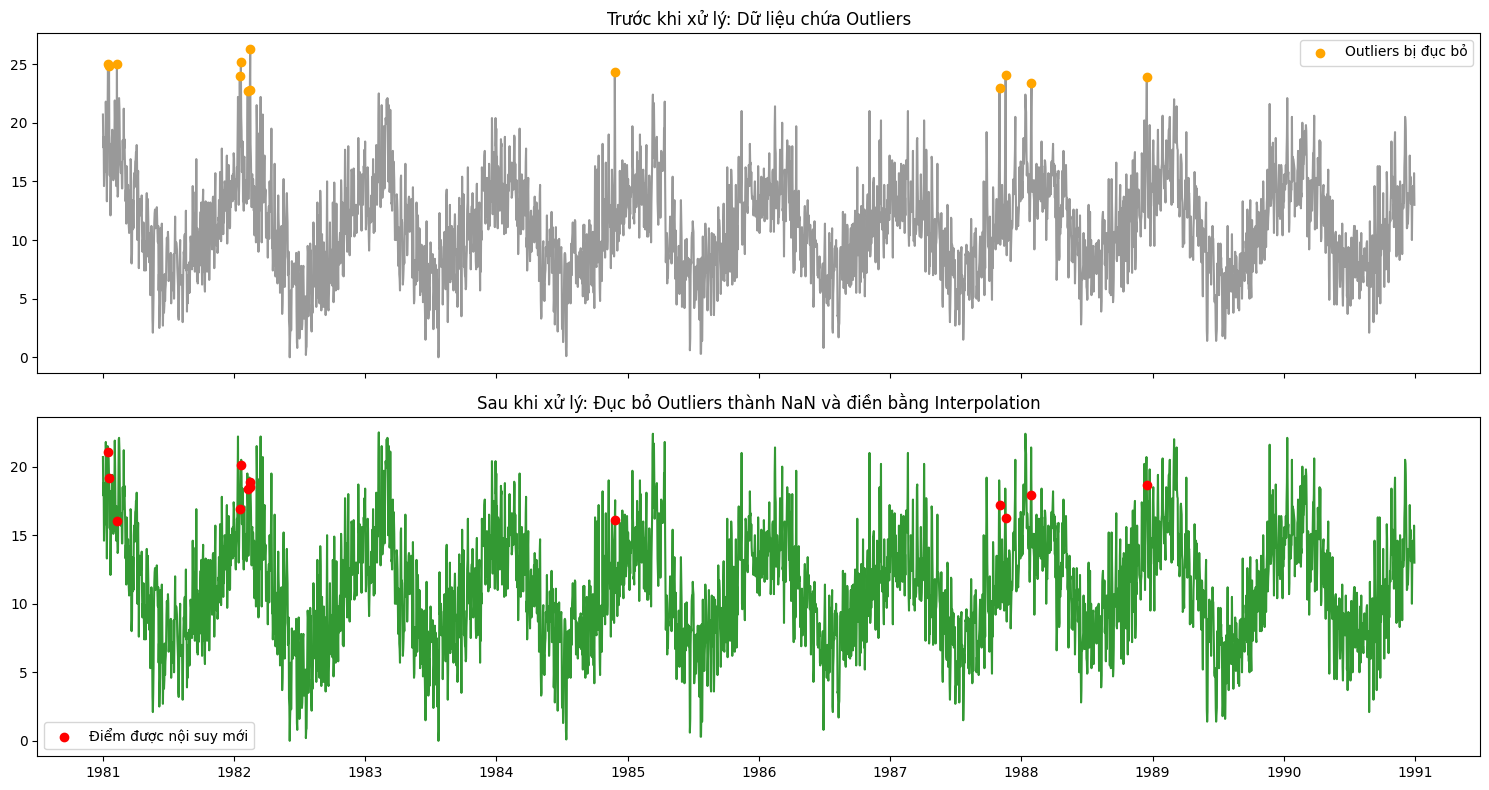

In [25]:
# Cách 2: Biến Outlier thành Missing (Ko khuyên dùng tránh trường hợp dữ liệu có giá trị)
df_handled_2 = df_outliers.copy()
mask_outliers = (df_handled_2['Temp'] < lower_bound) | (df_handled_2['Temp'] > upper_bound)
df_handled_2.loc[mask_outliers, 'Temp'] = np.nan
# Nội suy tuyến tính để lấp đầy các khoảng trống NaN vừa tạo
df_handled_2['Temp'] = df_handled_2['Temp'].interpolate(method='linear')
# Vẽ biểu đồ so sánh Trước và Sau
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
# 1. Trước khi xử lý
axes[0].plot(df_outliers.index, df_outliers['Temp'], color='gray', alpha=0.8)
axes[0].scatter(iqr_outliers.index, iqr_outliers['Temp'], color='orange', label='Outliers bị đục bỏ', zorder=5)
axes[0].set_title('Trước khi xử lý: Dữ liệu chứa Outliers')
axes[0].legend()
# 2. Sau khi xử lý bằng Interpolation
axes[1].plot(df_handled_2.index, df_handled_2['Temp'], color='green', alpha=0.8)
# Dùng mask để bôi đỏ những điểm vừa được nội suy tạo ra
axes[1].scatter(df_handled_2[mask_outliers].index, df_handled_2.loc[mask_outliers, 'Temp'], color='red', label='Điểm được nội suy mới', zorder=5)
axes[1].set_title('Sau khi xử lý: Đục bỏ Outliers thành NaN và điền bằng Interpolation')
axes[1].legend()
plt.tight_layout()
plt.show()

### Kết luận sử lý outlier